# 09: Regression Discontinuity Design RDD

We work through regression discontinuity design with `DoubleML` and the RDD tools available in the installed environment.

RDD is a local causal design. Treatment changes sharply or probabilistically at a cutoff in a running variable. The causal claim is not that treated and untreated units are comparable everywhere. The claim is narrower: units just below and just above the cutoff are comparable except for treatment assignment.

That local nature makes RDD both powerful and limited. It can be credible when the cutoff rule is real and hard to manipulate, but the estimand is usually a cutoff-local effect. A good RDD notebook therefore needs more than a single coefficient: it needs a running-variable plot, cutoff support checks, covariate continuity checks, bandwidth sensitivity, and clear reporting of the local target.

## Learning Goals

By the end, you should be able to:

- define the sharp and fuzzy RDD estimands;
- explain the continuity assumption at the cutoff;
- distinguish global treatment comparisons from local cutoff comparisons;
- construct `DoubleMLRDDData` with outcome, treatment, running score, and covariates;
- fit conventional `rdrobust` estimates and flexible `RDFlex` estimates;
- audit running-variable support, density, and covariate continuity;
- compare estimates across bandwidths;
- report RDD results with assumptions and local-scope caveats.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Regression Discontinuity Design RDD**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment uses a running variable and cutoff. The useful comparison is local to the threshold, so plots and bandwidth choices are part of the design evidence.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

Regression discontinuity uses a known cutoff in a running variable $R$. The sharp RDD estimand is

$$
\tau_{RDD}=\lim_{r\downarrow c}\mathbb{E}(Y\mid R=r)-\lim_{r\uparrow c}\mathbb{E}(Y\mid R=r).
$$

The identifying idea is local continuity of potential outcomes around $c$. The diagnostics are about bandwidth choice, smoothness, and manipulation near the cutoff.





## Tutorial Workflow

### RDD Intuition

An RDD starts with a score or running variable. Examples include an eligibility score, age, income, risk score, rating threshold, time relative to a cutoff, or an assignment priority index.

The cutoff creates a rule:

```text
D = 1 if score >= cutoff
D = 0 if score < cutoff
```

In a sharp RDD, the rule determines treatment exactly. In a fuzzy RDD, crossing the cutoff changes the probability of treatment, but some units do not comply with the cutoff rule.

The RDD estimand is a limit comparison:

```text
lim E[Y | score = cutoff from the right]
-
lim E[Y | score = cutoff from the left]
```

For fuzzy RDD, that outcome jump is divided by the treatment jump. This gives a local treatment effect for units whose treatment status is shifted by crossing the cutoff.

### Identification Assumptions

RDD identification relies on continuity near the cutoff. Potential outcomes should evolve smoothly through the cutoff in the absence of treatment. If units cannot precisely manipulate which side of the cutoff they land on, observations just below and just above the cutoff can be treated as locally comparable.

Important assumptions and diagnostics:

- **Continuity of potential outcomes:** without treatment, the conditional mean outcome would be smooth at the cutoff.
- **No precise manipulation:** units should not sort around the cutoff in a way that creates a discontinuity in unobserved determinants of the outcome.
- **Covariate continuity:** pre-treatment covariates should not jump at the cutoff.
- **Local support:** there should be enough observations on both sides near the cutoff.
- **Bandwidth sensitivity:** estimates should not depend entirely on one arbitrary window around the cutoff.

These diagnostics support the design story and make the assumption more transparent.

#### Where DoubleML Fits

Classic RDD uses local polynomial regression around the cutoff. `rdrobust` is a common implementation for bandwidth selection, bias correction, and robust intervals.

`DoubleML` adds a flexible adjustment workflow through `DoubleMLRDDData` and `RDFlex`. The idea is to use machine learning to adjust for observed covariates while preserving the local RDD logic. The running variable and cutoff still drive identification; machine learning is not a substitute for the cutoff design.

The installed environment has:

- `DoubleMLRDDData` for the RDD data backend;
- `doubleml.rdd.RDFlex` for flexible RDD adjustment;
- `rdrobust` for conventional RDD estimates.

### Runtime Note

This lesson fits conventional RDD estimates, flexible sharp RDD estimates, and a fuzzy RDD example. A full run should take about 1 to 3 minutes on a typical laptop.

#### Setup

The setup cell imports the scientific Python stack, DoubleML RDD classes, and `rdrobust`. A narrow warning filter suppresses an import-time `rdrobust` `SyntaxWarning` that is unrelated to this tutorial's computations.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in cast")
warnings.filterwarnings("ignore", message="IProgress not found.*", category=Warning)

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf

import doubleml as dml
from doubleml import DoubleMLRDDData
from doubleml.rdd import RDFlex
from rdrobust import rdrobust, rdbwselect

NOTEBOOK_PREFIX = "09"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

package_versions = pd.DataFrame(
    [
        {"package": "python", "version": os.sys.version.split()[0]},
        {"package": "doubleml", "version": dml.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "matplotlib", "version": plt.matplotlib.__version__},
        {"package": "seaborn", "version": sns.__version__},
    ]
)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,python,3.11.15
1,doubleml,0.11.2
2,numpy,2.4.4
3,pandas,3.0.2
4,scikit-learn,1.6.1
5,matplotlib,3.10.9
6,seaborn,0.13.2


The package table confirms that the optional RDD pieces are available in this environment. If this lesson is moved to another machine and the RDD imports fail, install the optional dependency with `uv add "doubleml[rdd]"`.

#### Helper Functions

The helper functions below implement transparent RDD calculations and output formatting. The manual local-linear estimates are not a replacement for `rdrobust`; they are included so the mechanics of bandwidth windows, side-specific slopes, and triangular weights are easy to see.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, file_name, index=False):
    """
    Save a table under the notebook output folder and return the DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    file_name : str
        Readable label for `file`.
    index : object
        Position of a row, variable, fold, or plotted node in the relevant ordered object.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / file_name
    df.to_csv(path, index=index)
    return df


def triangular_kernel(centered_score, bandwidth):
    """
    Triangular kernel weights for observations inside a bandwidth.
    
    Parameters
    ----------
    centered_score : array-like
        Score values for `centered`.
    bandwidth : float
        Window width around the regression-discontinuity cutoff.
    
    Returns
    -------
    np.ndarray
        Triangular kernel weights as a function of distance from the cutoff.
    """
    distance = np.abs(centered_score) / bandwidth
    return np.clip(1.0 - distance, 0.0, None)


def local_linear_rdd(df, y_col, score_col, cutoff=0.0, bandwidth=0.30, covariates=None, fuzzy_d_col=None):
    """
    Estimate a local-linear sharp or fuzzy RDD with triangular weights.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    y_col : str
        Outcome column name.
    score_col : str
        Column containing the ranking score or benefit signal.
    cutoff : object
        Running-variable threshold that defines treatment assignment in the RDD design.
    bandwidth : float
        Window width around the regression-discontinuity cutoff.
    covariates : object
        Covariate matrix or covariate names used for adjustment.
    fuzzy_d_col : object
        Treatment column used in the fuzzy regression-discontinuity calculation.
    
    Returns
    -------
    dict[str, float]
        Local-linear RDD summary with bandwidth, window sizes, estimate, standard error, interval, and p-value.
    """
    covariates = covariates or []
    work = df.loc[np.abs(df[score_col] - cutoff) <= bandwidth].copy()
    work["centered_score"] = work[score_col] - cutoff
    work["right_of_cutoff"] = (work["centered_score"] >= 0).astype(int)
    work["score_x_right"] = work["centered_score"] * work["right_of_cutoff"]
    weights = triangular_kernel(work["centered_score"].to_numpy(), bandwidth)

    x_cols = ["right_of_cutoff", "centered_score", "score_x_right"] + covariates
    X = sm.add_constant(work[x_cols], has_constant="add")
    y = work[y_col]
    reduced_form = sm.WLS(y, X, weights=weights).fit(cov_type="HC1")
    reduced_jump = float(reduced_form.params["right_of_cutoff"])
    reduced_se = float(reduced_form.bse["right_of_cutoff"])

    if fuzzy_d_col is None:
        return {
            "bandwidth": bandwidth,
            "n_window": len(work),
            "n_left": int((work["centered_score"] < 0).sum()),
            "n_right": int((work["centered_score"] >= 0).sum()),
            "estimate": reduced_jump,
            "std_error": reduced_se,
            "ci_95_lower": reduced_jump - 1.96 * reduced_se,
            "ci_95_upper": reduced_jump + 1.96 * reduced_se,
            "reduced_form_jump": reduced_jump,
            "first_stage_jump": np.nan,
        }

    first_stage = sm.WLS(work[fuzzy_d_col], X, weights=weights).fit(cov_type="HC1")
    first_jump = float(first_stage.params["right_of_cutoff"])
    first_se = float(first_stage.bse["right_of_cutoff"])
    fuzzy_estimate = reduced_jump / first_jump

    # A simple delta-method approximation that ignores covariance between first stage and reduced form.
    fuzzy_se = abs(fuzzy_estimate) * np.sqrt((reduced_se / reduced_jump) ** 2 + (first_se / first_jump) ** 2)
    return {
        "bandwidth": bandwidth,
        "n_window": len(work),
        "n_left": int((work["centered_score"] < 0).sum()),
        "n_right": int((work["centered_score"] >= 0).sum()),
        "estimate": fuzzy_estimate,
        "std_error": fuzzy_se,
        "ci_95_lower": fuzzy_estimate - 1.96 * fuzzy_se,
        "ci_95_upper": fuzzy_estimate + 1.96 * fuzzy_se,
        "reduced_form_jump": reduced_jump,
        "first_stage_jump": first_jump,
    }


def rdrobust_summary(result, label, design, true_target):
    """
    Extract conventional, bias-corrected, and robust rows from an rdrobust result.
    
    Parameters
    ----------
    result : object
        Result object or row whose fields are being formatted for display.
    label : str
        Readable label attached to the method, scenario, or output row.
    design : object
        Readable design label used to distinguish estimators or simulation settings.
    true_target : float
        Oracle causal target used to evaluate bias.
    
    Returns
    -------
    pd.DataFrame
        Summary table for rdrobust summary, with one row per method, scenario, group, or diagnostic check.
    """
    rows = []
    for method in result.coef.index:
        coef = float(result.coef.loc[method].iloc[0])
        ci_low = float(result.ci.loc[method].iloc[0])
        ci_high = float(result.ci.loc[method].iloc[1])
        rows.append(
            {
                "estimator": f"{label} - {method}",
                "design": design,
                "theta_hat": coef,
                "ci_95_lower": ci_low,
                "ci_95_upper": ci_high,
                "true_target": true_target,
                "bias_vs_target": coef - true_target,
            }
        )
    return pd.DataFrame(rows)


def rdflex_summary(model, label, design, true_target):
    """
    Extract conventional, bias-corrected, and robust rows from a fitted RDFlex object.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    label : str
        Readable label attached to the method, scenario, or output row.
    design : object
        Readable design label used to distinguish estimators or simulation settings.
    true_target : float
        Oracle causal target used to evaluate bias.
    
    Returns
    -------
    pd.DataFrame
        Summary table for rdflex summary, with one row per method, scenario, group, or diagnostic check.
    """
    method_names = ["Conventional", "Bias-Corrected", "Robust"]
    ci = model.confint(level=0.95)
    rows = []
    for i, method in enumerate(method_names):
        theta = float(model.coef[i])
        se = float(model.se[i])
        rows.append(
            {
                "estimator": f"{label} - {method}",
                "design": design,
                "theta_hat": theta,
                "std_error": se,
                "ci_95_lower": float(ci.iloc[i, 0]),
                "ci_95_upper": float(ci.iloc[i, 1]),
                "true_target": true_target,
                "bias_vs_target": theta - true_target,
            }
        )
    return pd.DataFrame(rows)


def add_ci_columns(df):
    """
    Prepare lower and upper error-bar columns for plotting.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    
    Returns
    -------
    pd.DataFrame
        Copy of the input table with lower and upper confidence-interval columns added.
    """
    out = df.copy()
    out["lower_error"] = out["theta_hat"] - out["ci_95_lower"]
    out["upper_error"] = out["ci_95_upper"] - out["theta_hat"]
    return out


The local-linear helper uses the standard RDD idea: fit separate local slopes on the left and right of the cutoff and read the discontinuity as the treatment effect. The flexible DoubleML estimator will later use machine-learning adjustment before applying RDD estimation logic.

#### Teaching Diagram

The RDD diagram is simpler than many causal diagrams because the key object is the cutoff. The running variable determines treatment status near the cutoff, and the outcome can vary smoothly with the running variable even without treatment.

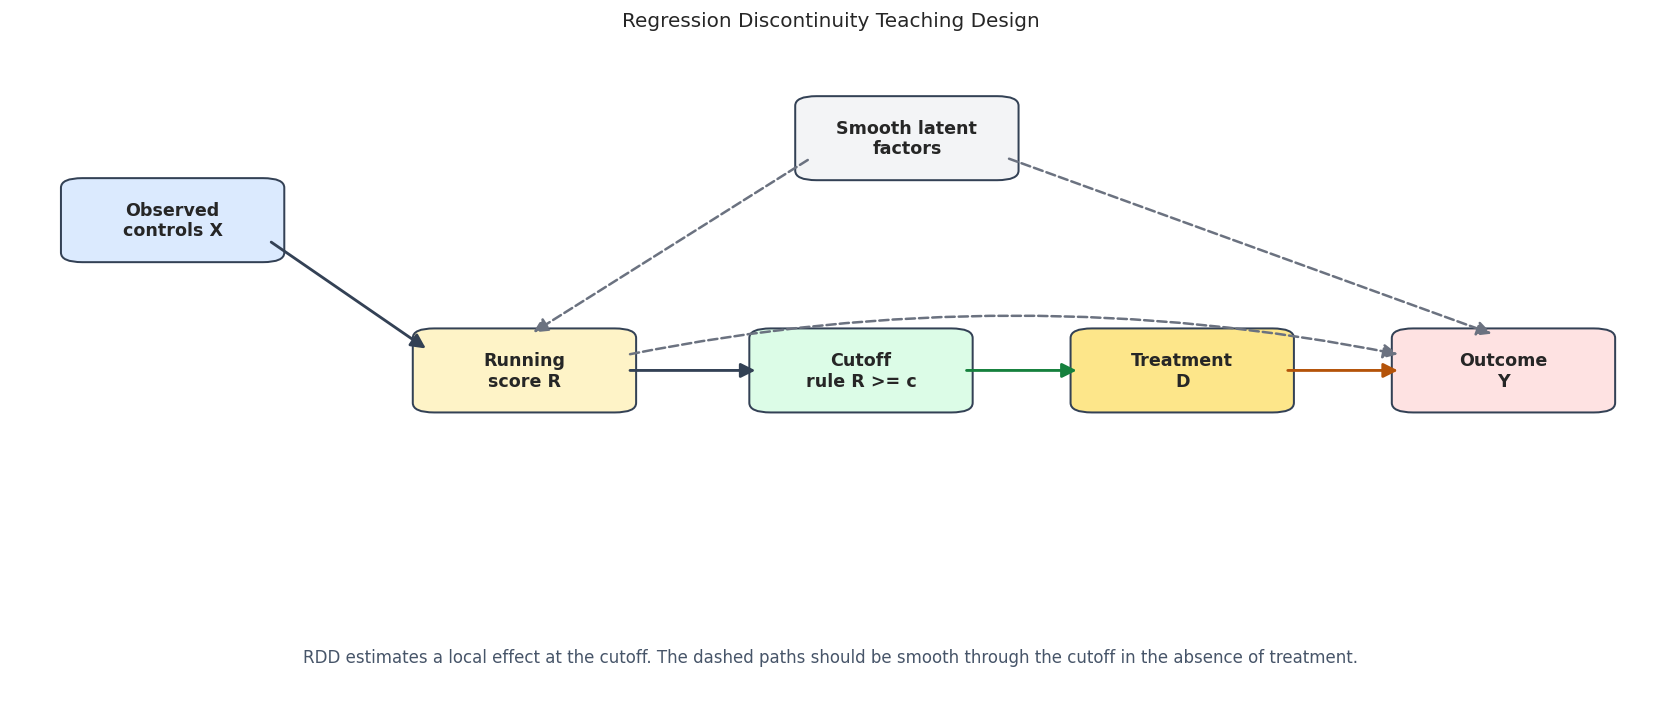

In [3]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

# The nodes are intentionally spaced across a wider canvas so the direction of the
# assignment path is easy to read. Smaller boxes also leave longer visible arrow lines.
nodes = {
    "X": {"xy": (0.07, 0.74), "label": "Observed\ncontrols X", "color": "#dbeafe"},
    "R": {"xy": (0.30, 0.52), "label": "Running\nscore R", "color": "#fef3c7"},
    "C": {"xy": (0.52, 0.52), "label": "Cutoff\nrule R >= c", "color": "#dcfce7"},
    "D": {"xy": (0.73, 0.52), "label": "Treatment\nD", "color": "#fde68a"},
    "Y": {"xy": (0.94, 0.52), "label": "Outcome\nY", "color": "#fee2e2"},
    "U": {"xy": (0.55, 0.86), "label": "Smooth latent\nfactors", "color": "#f3f4f6"},
}

fig, ax = plt.subplots(figsize=(14, 6.2))
ax.set_axis_off()
ax.set_xlim(-0.035, 1.035)
ax.set_ylim(0.02, 0.98)
box_w, box_h = 0.118, 0.095
arrow_gap = 0.010


def anchor(node, side):
    """
    Idea: Return the plotting anchor point for a named node in the diagram.
    
    Parameters
    ----------
    node : object
        Graph node whose position, label, or incident edges are being processed.
    side : object
        Endpoint side used to place an arrow or edge on the correct part of a node.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return np.array([x + dx, y + dy], dtype=float)


def shorten(start, end, gap=arrow_gap):
    """
    Idea: Shorten a line segment so the arrowhead remains visible outside the node box.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[float, float]
        Shortened endpoint coordinate that keeps an arrowhead visible.
    """
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    length = np.hypot(delta[0], delta[1])
    if length == 0:
        return tuple(start), tuple(end)
    unit = delta / length
    return tuple(start + gap * unit), tuple(end - gap * unit)


def draw_arrow(start, end, color, style="solid", rad=0.0, linewidth=1.7):
    """
    Idea: Draw a routed arrow between diagram nodes while keeping the arrowhead visible.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    rad : float
        Curvature parameter for the plotted arrow.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start, end = shorten(start, end)
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        shrinkA=0,
        shrinkB=0,
        connectionstyle=f"arc3,rad={rad}",
        zorder=5,
    )
    ax.add_patch(arrow)

# Main assignment path.
draw_arrow(anchor("X", "lower_right"), anchor("R", "upper_left"), color="#334155")
draw_arrow(anchor("R", "right"), anchor("C", "left"), color="#334155")
draw_arrow(anchor("C", "right"), anchor("D", "left"), color="#15803d")
draw_arrow(anchor("D", "right"), anchor("Y", "left"), color="#b45309")

# Smooth background paths remind us what continuity means.
draw_arrow(anchor("R", "upper_right"), anchor("Y", "upper_left"), color="#6b7280", style="dashed", rad=-0.10, linewidth=1.5)
draw_arrow(anchor("U", "lower_left"), anchor("R", "top"), color="#6b7280", style="dashed", linewidth=1.5)
draw_arrow(anchor("U", "lower_right"), anchor("Y", "top"), color="#6b7280", style="dashed", linewidth=1.5)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.014",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=4)

ax.text(
    0.50,
    0.10,
    "RDD estimates a local effect at the cutoff. The dashed paths should be smooth through the cutoff in the absence of treatment.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Regression Discontinuity Teaching Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_rdd_design_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The diagram highlights the central design logic. The running score can affect the outcome smoothly, but the discontinuous change in treatment at the cutoff is what identifies the local effect.

#### Synthetic Sharp RDD Data

The first dataset is a sharp RDD. Treatment is exactly assigned by whether the running score is above the cutoff. The outcome also depends smoothly on the score and observed covariates. The true jump at the cutoff is `1.2`.

Because this is synthetic data, we know the truth. In real data, the best we can do is argue that the cutoff is credible and show diagnostics.

In [4]:
# Save the artifacts produced by the Synthetic Sharp RDD Data section.
rng = np.random.default_rng(RANDOM_SEED)
N_SHARP = 4_500
CUTOFF = 0.0
TRUE_SHARP_EFFECT = 1.20

score = rng.uniform(-1, 1, N_SHARP)
engagement_score = rng.normal(0, 1, N_SHARP)
baseline_value = rng.normal(0, 1, N_SHARP)
mobile_user = rng.binomial(1, 0.45, N_SHARP)

sharp_treatment = (score >= CUTOFF).astype(int)
smooth_score_component = 1.40 * score + 0.80 * score**2 - 0.35 * score**3
covariate_component = 0.55 * engagement_score - 0.35 * baseline_value + 0.20 * mobile_user
sharp_outcome = 2.00 + smooth_score_component + covariate_component + TRUE_SHARP_EFFECT * sharp_treatment + rng.normal(0, 0.60, N_SHARP)

sharp_df = pd.DataFrame(
    {
        "row_id": np.arange(N_SHARP),
        "outcome": sharp_outcome,
        "treatment": sharp_treatment,
        "running_score": score,
        "engagement_score": engagement_score,
        "baseline_value": baseline_value,
        "mobile_user": mobile_user,
        "smooth_score_component": smooth_score_component,
        "true_effect_at_cutoff": TRUE_SHARP_EFFECT,
    }
)
feature_cols = ["engagement_score", "baseline_value", "mobile_user"]

sharp_path = DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_sharp_rdd.csv"
sharp_df.to_csv(sharp_path, index=False)

print(f"Rows: {len(sharp_df):,}")
print(f"Cutoff: {CUTOFF:.1f}")
print(f"True sharp RDD effect at cutoff: {TRUE_SHARP_EFFECT:.3f}")
print(f"Saved data to: {sharp_path.relative_to(PROJECT_ROOT)}")
display(sharp_df.head())


Rows: 4,500
Cutoff: 0.0
True sharp RDD effect at cutoff: 1.200
Saved data to: notebooks/tutorials/doubleml/outputs/datasets/09_synthetic_sharp_rdd.csv


,row_id,outcome,treatment,running_score,engagement_score,baseline_value,mobile_user,smooth_score_component,true_effect_at_cutoff
0,0,4.935937,1,0.547912,0.065983,0.890045,0,0.949672,1.2
1,1,0.528297,0,-0.122243,-0.464412,1.299978,0,-0.158546,1.2
2,2,3.570701,1,0.717196,-1.014069,-0.110422,0,1.286454,1.2
3,3,3.740875,1,0.394736,-1.266596,-0.862670,1,0.655756,1.2
4,4,1.158950,0,-0.811645,-0.048484,2.109985,1,-0.422149,1.2


Treatment switches exactly at the cutoff. The outcome is not flat in the running score, which is realistic. RDD does not require the outcome to be flat; it requires the no-treatment outcome function to be smooth through the cutoff.

#### Sharp RDD Field Dictionary

The field dictionary makes the causal roles explicit. The running score is not an ordinary control; it is the assignment variable that defines the local comparison.

| field | role | description |
| --- | --- | --- |
| row_id | identifier | Unique row identifier. |
| outcome | outcome | Observed outcome Y. |
| treatment | treatment | Sharp treatment indicator D = 1[running_score >= cutoff]. |
| running_score | running variable | Assignment score that determines treatment at the cutoff. |
| engagement_score | covariate | Observed pre-assignment covariate. |
| baseline_value | covariate | Observed pre-assignment baseline predictor. |
| mobile_user | covariate | Observed binary segment marker. |
| smooth_score_component | simulation truth | Smooth no-treatment score component. |
| true_effect_at_cutoff | simulation truth | True discontinuous effect at the cutoff. |


The most important roles are `running_score`, `treatment`, and `outcome`. If the cutoff rule is incorrectly encoded, every downstream estimate answers the wrong question.




## Diagnostics and Interpretation

### Basic Audit and Local Support

The first audit checks sample size, treatment share, and how many observations fall near the cutoff. RDD is a local design, so the rows near zero matter most.

In [5]:
# Save the artifacts produced by the Basic Audit And Local Support section.
window_counts = []
for h in [0.10, 0.20, 0.30, 0.40, 0.60]:
    in_window = sharp_df.loc[sharp_df["running_score"].abs() <= h]
    window_counts.append(
        {
            "bandwidth": h,
            "n_window": len(in_window),
            "n_left": int((in_window["running_score"] < 0).sum()),
            "n_right": int((in_window["running_score"] >= 0).sum()),
        }
    )

sharp_audit = pd.DataFrame(
    [
        {"metric": "rows", "value": len(sharp_df)},
        {"metric": "missing_cells", "value": int(sharp_df.isna().sum().sum())},
        {"metric": "treatment_share", "value": sharp_df["treatment"].mean()},
        {"metric": "min_running_score", "value": sharp_df["running_score"].min()},
        {"metric": "max_running_score", "value": sharp_df["running_score"].max()},
    ]
)
sharp_window_counts = pd.DataFrame(window_counts)
save_table(sharp_audit, f"{NOTEBOOK_PREFIX}_sharp_data_audit.csv")
save_table(sharp_window_counts, f"{NOTEBOOK_PREFIX}_sharp_window_counts.csv")
display(sharp_audit)
display(sharp_window_counts)


,metric,value
0,rows,4500.000000
1,missing_cells,0.000000
2,treatment_share,0.495556
3,min_running_score,-0.998963
4,max_running_score,0.999531


,bandwidth,n_window,n_left,n_right
0,0.1,463,235,228
1,0.2,924,464,460
2,0.3,1335,663,672
3,0.4,1777,892,885
4,0.6,2666,1338,1328


The local windows have observations on both sides of the cutoff. That is a minimal requirement for RDD; without local support, the estimate would be extrapolation rather than a local comparison.

### Running-Variable Distribution

A running-variable density check looks for suspicious bunching around the cutoff. In real data, a large density jump can suggest manipulation or sorting. Here the score is generated smoothly, so no jump should appear.

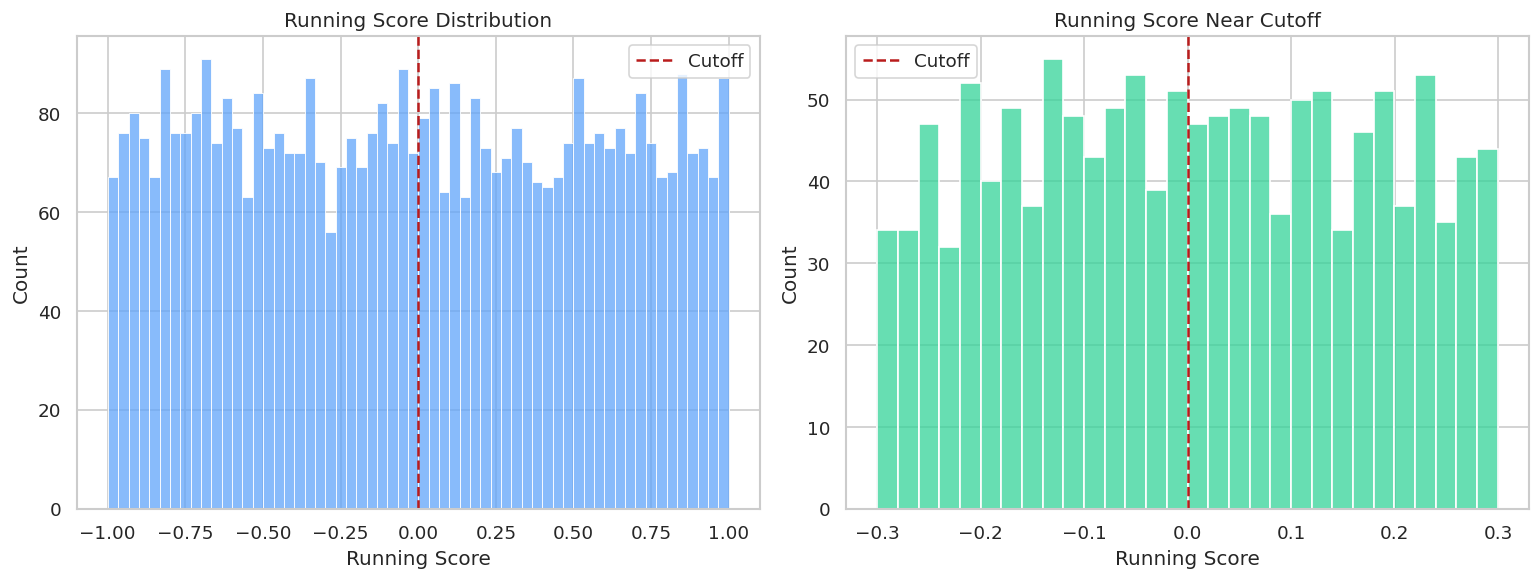

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=sharp_df, x="running_score", bins=60, color="#60a5fa", ax=axes[0])
axes[0].axvline(CUTOFF, color="#b91c1c", linestyle="--", linewidth=1.5, label="Cutoff")
axes[0].set_title("Running Score Distribution")
axes[0].set_xlabel("Running Score")
axes[0].set_ylabel("Count")
axes[0].legend()

near = sharp_df.loc[sharp_df["running_score"].abs() <= 0.30].copy()
sns.histplot(data=near, x="running_score", bins=30, color="#34d399", ax=axes[1])
axes[1].axvline(CUTOFF, color="#b91c1c", linestyle="--", linewidth=1.5, label="Cutoff")
axes[1].set_title("Running Score Near Cutoff")
axes[1].set_xlabel("Running Score")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_running_score_density.png", dpi=160, bbox_inches="tight")
plt.show()


The histogram is smooth around the cutoff. That supports the no-precise-manipulation story in this synthetic setting.

The figure matters because it turns the numeric output into a pattern that can be inspected before trusting the next modeling step.
<!-- result-implication-expanded -->




#### Binned RDD Plot

The binned plot is the classic first RDD visualization. It shows average outcomes in running-score bins and overlays local linear fits near the cutoff.

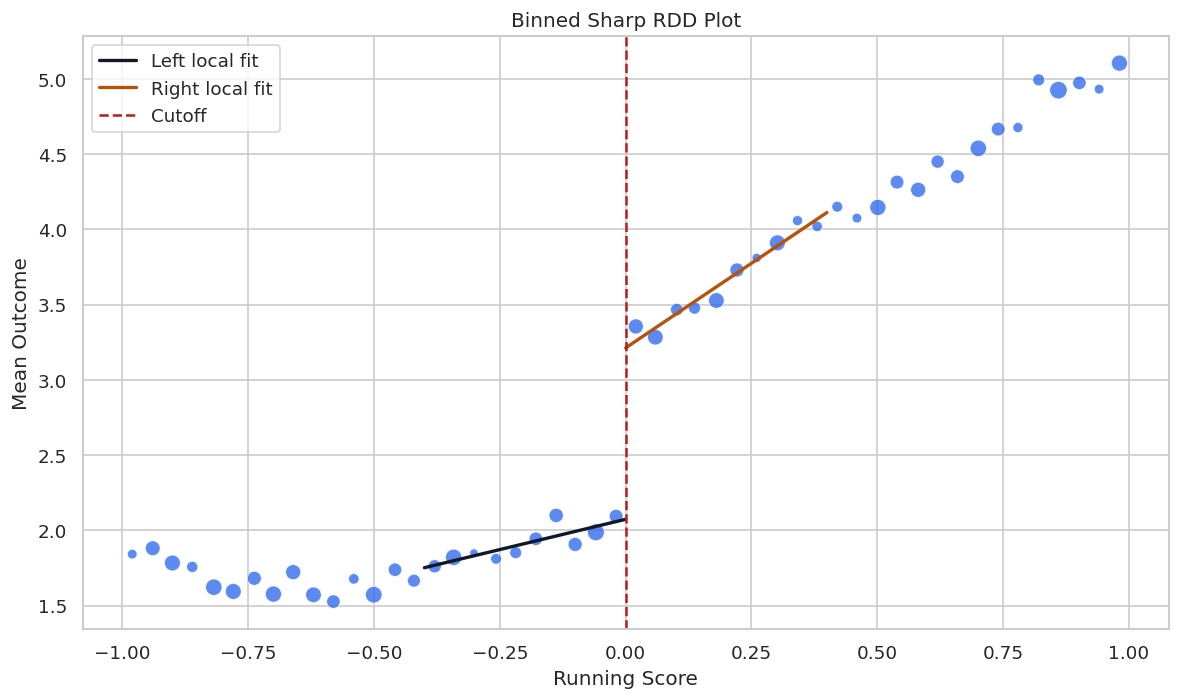

In [7]:
# Build and label the diagnostic visualization for the Binned RDD Plot section.
bins = np.linspace(-1, 1, 51)
sharp_df["score_bin"] = pd.cut(sharp_df["running_score"], bins=bins, include_lowest=True)
rd_bins = (
    sharp_df.groupby("score_bin", observed=True)
    .agg(
        bin_mid=("running_score", "mean"),
        mean_outcome=("outcome", "mean"),
        n=("outcome", "size"),
    )
    .reset_index(drop=True)
)
save_table(rd_bins, f"{NOTEBOOK_PREFIX}_sharp_binned_outcomes.csv")

plot_window = sharp_df.loc[sharp_df["running_score"].abs() <= 0.40].copy()
left_fit = smf.ols("outcome ~ running_score", data=plot_window.loc[plot_window["running_score"] < 0]).fit()
right_fit = smf.ols("outcome ~ running_score", data=plot_window.loc[plot_window["running_score"] >= 0]).fit()
score_grid_left = pd.DataFrame({"running_score": np.linspace(-0.40, 0, 100)})
score_grid_right = pd.DataFrame({"running_score": np.linspace(0, 0.40, 100)})
score_grid_left["prediction"] = left_fit.predict(score_grid_left)
score_grid_right["prediction"] = right_fit.predict(score_grid_right)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=rd_bins, x="bin_mid", y="mean_outcome", size="n", sizes=(25, 110), color="#2563eb", alpha=0.75, ax=ax, legend=False)
ax.plot(score_grid_left["running_score"], score_grid_left["prediction"], color="#111827", linewidth=2, label="Left local fit")
ax.plot(score_grid_right["running_score"], score_grid_right["prediction"], color="#b45309", linewidth=2, label="Right local fit")
ax.axvline(CUTOFF, color="#b91c1c", linestyle="--", linewidth=1.5, label="Cutoff")
ax.set_title("Binned Sharp RDD Plot")
ax.set_xlabel("Running Score")
ax.set_ylabel("Mean Outcome")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sharp_binned_rdd_plot.png", dpi=160, bbox_inches="tight")
plt.show()


The jump at the cutoff is visible, while the outcome also changes smoothly with the running score. That is exactly the pattern RDD is designed to handle.

### Covariate Continuity Checks

Pre-assignment covariates should not jump at the cutoff. If they do, observations just above and below the cutoff may not be locally comparable.

The table below estimates local discontinuities in each covariate using the same local-linear helper.

In [8]:
covariate_checks = []
for covariate in feature_cols:
    row = local_linear_rdd(
        sharp_df,
        y_col=covariate,
        score_col="running_score",
        cutoff=CUTOFF,
        bandwidth=0.30,
        covariates=[],
    )
    covariate_checks.append(
        {
            "covariate": covariate,
            "bandwidth": row["bandwidth"],
            "jump_estimate": row["estimate"],
            "std_error": row["std_error"],
            "ci_95_lower": row["ci_95_lower"],
            "ci_95_upper": row["ci_95_upper"],
            "n_window": row["n_window"],
        }
    )

covariate_continuity = pd.DataFrame(covariate_checks)
save_table(covariate_continuity, f"{NOTEBOOK_PREFIX}_covariate_continuity_checks.csv")
display(covariate_continuity)


,covariate,bandwidth,jump_estimate,std_error,ci_95_lower,ci_95_upper,n_window
0,engagement_score,0.3,-0.147086,0.113817,-0.370167,0.075996,1335
1,baseline_value,0.3,-0.000684,0.122394,-0.240577,0.239208,1335
2,mobile_user,0.3,0.061086,0.058723,-0.054011,0.176183,1335


The covariate jumps are small relative to their uncertainty. That is what we expect in the synthetic design because covariates were generated smoothly with respect to the score.

#### Manual Local-Linear RDD Estimates

Now we estimate the sharp RDD effect manually across bandwidths. Narrow bandwidths are more local but noisier. Wider bandwidths are more precise but rely more heavily on functional-form approximation away from the cutoff.

In [9]:
# Save the artifacts produced by the Manual Local-Linear RDD Estimates section.
bandwidth_grid = [0.12, 0.18, 0.24, 0.30, 0.40, 0.55]
manual_rows = []
for h in bandwidth_grid:
    no_cov = local_linear_rdd(
        sharp_df,
        y_col="outcome",
        score_col="running_score",
        cutoff=CUTOFF,
        bandwidth=h,
        covariates=[],
    )
    no_cov.update({"estimator": "Manual local linear", "covariate_adjusted": False})
    manual_rows.append(no_cov)

    cov_adj = local_linear_rdd(
        sharp_df,
        y_col="outcome",
        score_col="running_score",
        cutoff=CUTOFF,
        bandwidth=h,
        covariates=feature_cols,
    )
    cov_adj.update({"estimator": "Manual local linear + covariates", "covariate_adjusted": True})
    manual_rows.append(cov_adj)

manual_bandwidth_sensitivity = pd.DataFrame(manual_rows)
manual_bandwidth_sensitivity["true_target"] = TRUE_SHARP_EFFECT
manual_bandwidth_sensitivity["bias_vs_target"] = manual_bandwidth_sensitivity["estimate"] - TRUE_SHARP_EFFECT
save_table(manual_bandwidth_sensitivity, f"{NOTEBOOK_PREFIX}_manual_bandwidth_sensitivity.csv")
display(manual_bandwidth_sensitivity)


,bandwidth,n_window,n_left,n_right,estimate,std_error,ci_95_lower,ci_95_upper,reduced_form_jump,first_stage_jump,estimator,covariate_adjusted,true_target,bias_vs_target
0,0.12,561,283,278,1.188797,0.163678,0.867988,1.509607,1.188797,NaN,Manual local linear,False,1.2,-0.011203
1,0.12,561,283,278,1.346222,0.123593,1.103981,1.588463,1.346222,NaN,Manual local linear + covariates,True,1.2,0.146222
2,0.18,835,424,411,1.239125,0.135525,0.973496,1.504754,1.239125,NaN,Manual local linear,False,1.2,0.039125
3,0.18,835,424,411,1.331529,0.099800,1.135922,1.527136,1.331529,NaN,Manual local linear + covariates,True,1.2,0.131529
4,0.24,1099,548,551,1.233916,0.117339,1.003932,1.463901,1.233916,NaN,Manual local linear,False,1.2,0.033916
5,0.24,1099,548,551,1.295191,0.084872,1.128842,1.461539,1.295191,NaN,Manual local linear + covariates,True,1.2,0.095191
6,0.30,1335,663,672,1.200839,0.105605,0.993852,1.407825,1.200839,NaN,Manual local linear,False,1.2,0.000839
7,0.30,1335,663,672,1.267491,0.075631,1.119255,1.415728,1.267491,NaN,Manual local linear + covariates,True,1.2,0.067491
8,0.40,1777,892,885,1.166836,0.091309,0.987871,1.345801,1.166836,NaN,Manual local linear,False,1.2,-0.033164
9,0.40,1777,892,885,1.236469,0.064381,1.110282,1.362656,1.236469,NaN,Manual local linear + covariates,True,1.2,0.036469


The estimates are reasonably stable across bandwidths. Covariate adjustment can improve precision, but the running-score cutoff still supplies the identifying variation.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




#### Bandwidth Sensitivity Plot

A plot makes bandwidth sensitivity easier to inspect than a table. We want estimates to move somewhat as bandwidth changes, but not to tell completely different stories across reasonable windows.

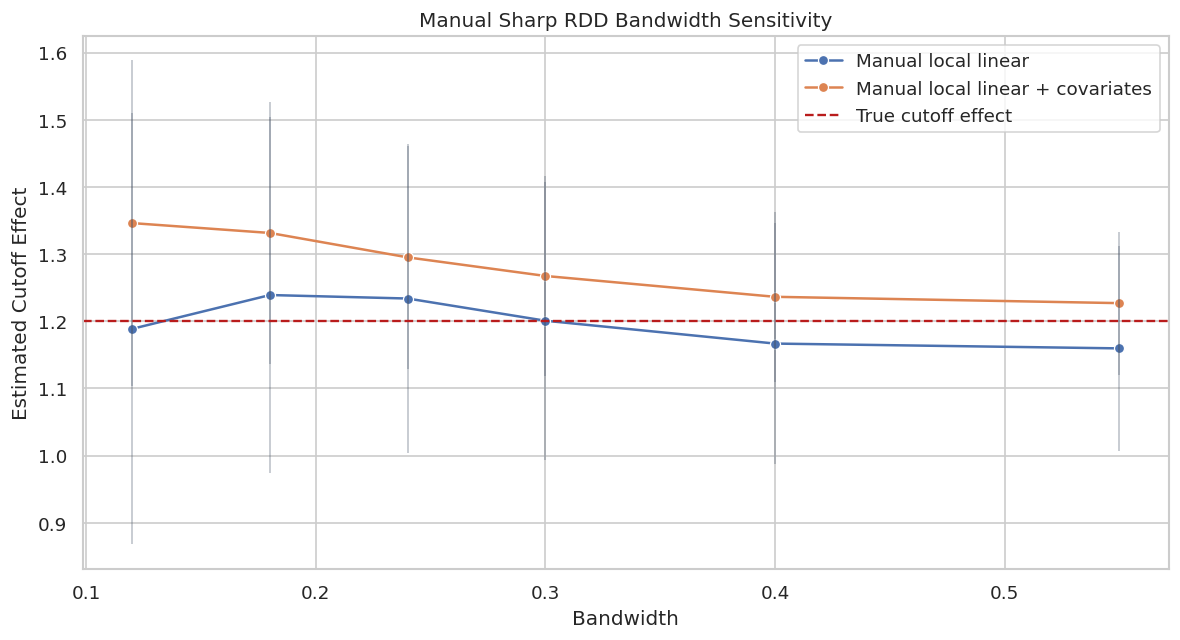

In [10]:
# Build and label the diagnostic visualization for the Bandwidth Sensitivity Plot section.
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=manual_bandwidth_sensitivity,
    x="bandwidth",
    y="estimate",
    hue="estimator",
    marker="o",
    ax=ax,
)
for _, row in manual_bandwidth_sensitivity.iterrows():
    ax.vlines(
        row["bandwidth"],
        row["ci_95_lower"],
        row["ci_95_upper"],
        color="#475569",
        alpha=0.35,
        linewidth=1,
    )
ax.axhline(TRUE_SHARP_EFFECT, color="#b91c1c", linestyle="--", linewidth=1.4, label="True cutoff effect")
ax.set_title("Manual Sharp RDD Bandwidth Sensitivity")
ax.set_xlabel("Bandwidth")
ax.set_ylabel("Estimated Cutoff Effect")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_bandwidth_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The plot shows the bias-variance tradeoff. The smallest windows are noisier, while very wide windows can be more sensitive to curvature away from the cutoff.



#### Conventional `rdrobust` Estimate

`rdrobust` is a standard RDD tool for local-polynomial estimation, bandwidth selection, bias correction, and robust confidence intervals. The output reports conventional, bias-corrected, and robust rows.

In [11]:
rdrobust_sharp = rdrobust(
    y=sharp_df["outcome"].to_numpy(),
    x=sharp_df["running_score"].to_numpy(),
    c=CUTOFF,
)
rdrobust_sharp_summary = rdrobust_summary(rdrobust_sharp, "rdrobust sharp", "sharp RDD", TRUE_SHARP_EFFECT)
save_table(rdrobust_sharp_summary, f"{NOTEBOOK_PREFIX}_rdrobust_sharp_summary.csv")
print(rdrobust_sharp)
display(rdrobust_sharp_summary)

Call: rdrobust
Number of Observations:                  4500
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          2270       2230
Number of Unique Obs.           2270       2230
Number of Effective Obs.         582        579
Bandwidth Estimation           0.254      0.254
Bandwidth Bias                 0.399      0.399
rho (h/b)                      0.636      0.636

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       1.227    0.116   10.574   3.929e-26     [0.999, 1.454]
Robust                 -        -    9.169   4.785e-20     [0.988, 1.526]



,estimator,design,theta_hat,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,rdrobust sharp - Conventional,sharp RDD,1.226608,0.999250,1.453966,1.2,0.026608
1,rdrobust sharp - Bias-Corrected,sharp RDD,1.257036,1.029678,1.484394,1.2,0.057036
2,rdrobust sharp - Robust,sharp RDD,1.257036,0.988325,1.525747,1.2,0.057036


The robust interval is usually the row to emphasize from `rdrobust`, while the conventional row is useful for orientation. The estimate is close to the true cutoff jump in this synthetic design.

#### DoubleML RDD Data Backend

`DoubleMLRDDData` gives DoubleML the outcome, treatment, running score, and optional covariates. The score column has a special role; it is not simply another predictor.

In [12]:
sharp_rdd_data = DoubleMLRDDData(
    sharp_df,
    y_col="outcome",
    d_cols="treatment",
    score_col="running_score",
    x_cols=feature_cols,
)

sharp_backend_summary = pd.DataFrame(
    [
        {"property": "n_obs", "value": sharp_rdd_data.n_obs},
        {"property": "outcome", "value": sharp_rdd_data.y_col},
        {"property": "treatment", "value": ", ".join(sharp_rdd_data.d_cols)},
        {"property": "score", "value": sharp_rdd_data.score_col},
        {"property": "n_covariates", "value": len(sharp_rdd_data.x_cols)},
        {"property": "covariates", "value": ", ".join(sharp_rdd_data.x_cols)},
    ]
)
save_table(sharp_backend_summary, f"{NOTEBOOK_PREFIX}_sharp_rdd_backend.csv")
display(sharp_backend_summary)


,property,value
0,n_obs,4500
1,outcome,outcome
2,treatment,treatment
3,score,running_score
4,n_covariates,3
5,covariates,"engagement_score, baseline_value, mobile_user"


This backend object is the contract for the flexible RDD estimator. If `score_col` is wrong, the cutoff comparison is wrong.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### Fit `RDFlex` for Sharp RDD

`RDFlex` uses machine-learning adjustment for covariates and then applies RDD estimation logic. The learner for `ml_g` must support `sample_weight`; the tree learners used here do.

In [13]:
# Fit or evaluate the model objects used in the Fit `RDFlex` For Sharp RDD section.
rdflex_rows = []
rdflex_models = {}

rf_g = RandomForestRegressor(
    n_estimators=120,
    max_depth=6,
    min_samples_leaf=15,
    random_state=RANDOM_SEED,
)
rdflex_rf = RDFlex(
    sharp_rdd_data,
    ml_g=rf_g,
    fuzzy=False,
    cutoff=CUTOFF,
    n_folds=5,
    h_fs=0.40,
)
rdflex_rf.fit(n_iterations=1)
rdflex_models["RDFlex sharp RF"] = rdflex_rf
rdflex_rows.append(rdflex_summary(rdflex_rf, "RDFlex sharp RF", "sharp RDD", TRUE_SHARP_EFFECT))

hgb_g = HistGradientBoostingRegressor(
    max_iter=80,
    max_leaf_nodes=15,
    min_samples_leaf=25,
    learning_rate=0.06,
    random_state=RANDOM_SEED + 1,
)
rdflex_hgb = RDFlex(
    sharp_rdd_data,
    ml_g=hgb_g,
    fuzzy=False,
    cutoff=CUTOFF,
    n_folds=5,
    h_fs=0.40,
)
rdflex_hgb.fit(n_iterations=1)
rdflex_models["RDFlex sharp HGB"] = rdflex_hgb
rdflex_rows.append(rdflex_summary(rdflex_hgb, "RDFlex sharp HGB", "sharp RDD", TRUE_SHARP_EFFECT))

rdflex_sharp_summary = pd.concat(rdflex_rows, ignore_index=True)
save_table(rdflex_sharp_summary, f"{NOTEBOOK_PREFIX}_rdflex_sharp_summary.csv")
display(rdflex_sharp_summary)


,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,RDFlex sharp RF - Conventional,sharp RDD,1.341511,0.091887,1.161417,1.521606,1.2,0.141511
1,RDFlex sharp RF - Bias-Corrected,sharp RDD,1.374532,0.091887,1.194438,1.554627,1.2,0.174532
2,RDFlex sharp RF - Robust,sharp RDD,1.374532,0.106352,1.166085,1.582979,1.2,0.174532
3,RDFlex sharp HGB - Conventional,sharp RDD,1.272604,0.089548,1.097094,1.448115,1.2,0.072604
4,RDFlex sharp HGB - Bias-Corrected,sharp RDD,1.300154,0.089548,1.124644,1.475665,1.2,0.100154
5,RDFlex sharp HGB - Robust,sharp RDD,1.300154,0.105599,1.093184,1.507125,1.2,0.100154


The flexible estimates are close to the cutoff effect. Differences across learners are expected because the nuisance adjustment is learned from data and the estimate remains local.



#### Sharp RDD Estimate Comparison

This plot combines manual local-linear estimates, `rdrobust`, and `RDFlex`. It focuses on the robust or main rows rather than showing every row from every estimator.

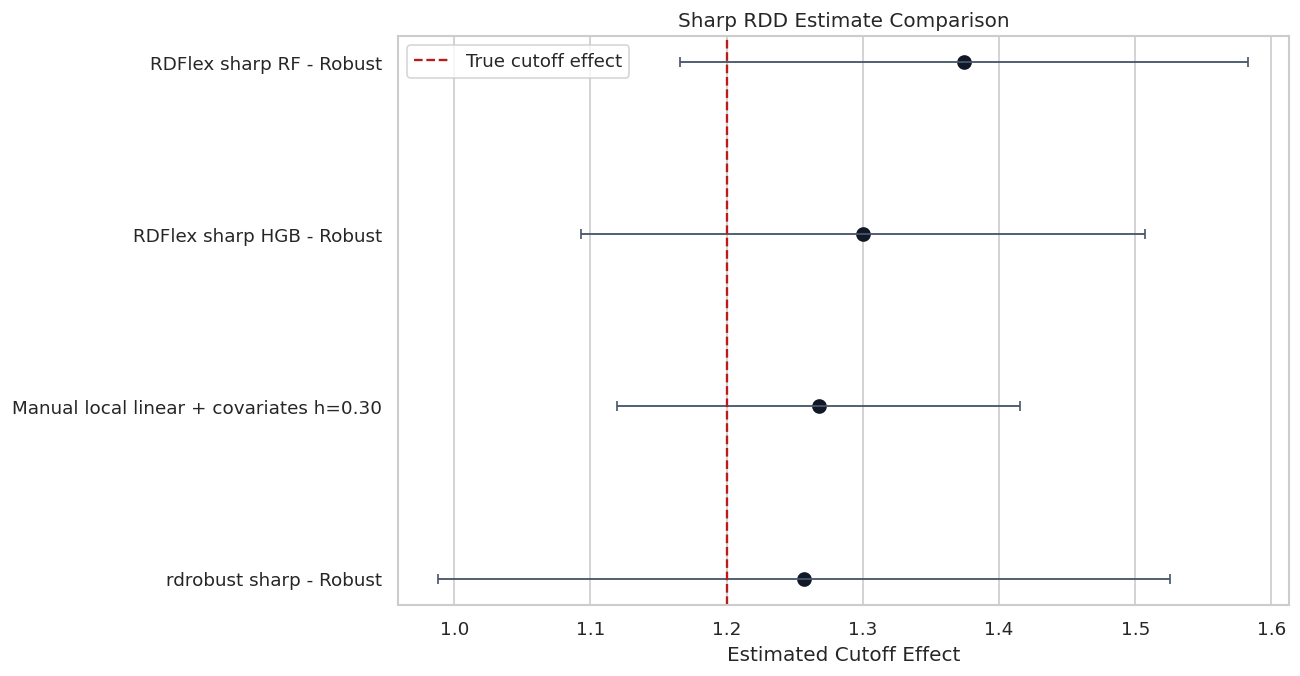

,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,Manual local linear + covariates h=0.30,sharp RDD,1.267491,0.075631,1.119255,1.415728,1.2,0.067491
1,rdrobust sharp - Robust,sharp RDD,1.257036,NaN,0.988325,1.525747,1.2,0.057036
2,RDFlex sharp RF - Robust,sharp RDD,1.374532,0.106352,1.166085,1.582979,1.2,0.174532
3,RDFlex sharp HGB - Robust,sharp RDD,1.300154,0.105599,1.093184,1.507125,1.2,0.100154


In [14]:
# Build and label the diagnostic visualization for the Sharp RDD Estimate Comparison section.
manual_primary = manual_bandwidth_sensitivity.query("bandwidth == 0.30 and covariate_adjusted == True").copy()
manual_primary = manual_primary.rename(columns={"estimate": "theta_hat"})
manual_primary["estimator"] = "Manual local linear + covariates h=0.30"
manual_primary["design"] = "sharp RDD"
manual_primary["true_target"] = TRUE_SHARP_EFFECT
manual_primary["bias_vs_target"] = manual_primary["theta_hat"] - TRUE_SHARP_EFFECT
manual_primary = manual_primary[["estimator", "design", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "true_target", "bias_vs_target"]]

rdrobust_primary = rdrobust_sharp_summary.loc[rdrobust_sharp_summary["estimator"] == "rdrobust sharp - Robust"].copy()
rdrobust_primary["std_error"] = np.nan
rdflex_primary = rdflex_sharp_summary.loc[rdflex_sharp_summary["estimator"].str.endswith("Robust")].copy()

sharp_estimate_comparison = pd.concat(
    [manual_primary, rdrobust_primary, rdflex_primary],
    ignore_index=True,
    sort=False,
)
save_table(sharp_estimate_comparison, f"{NOTEBOOK_PREFIX}_sharp_estimate_comparison.csv")
plot_sharp = add_ci_columns(sharp_estimate_comparison)

fig, ax = plt.subplots(figsize=(11, 5.8))
order = plot_sharp.sort_values("theta_hat", ascending=False)["estimator"]
sns.pointplot(
    data=plot_sharp,
    y="estimator",
    x="theta_hat",
    order=order,
    linestyle="none",
    color="#111827",
    errorbar=None,
    ax=ax,
)
for y_pos, (_, row) in enumerate(plot_sharp.set_index("estimator").loc[order].reset_index().iterrows()):
    ax.errorbar(
        x=row["theta_hat"],
        y=y_pos,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="none",
        color="#475569",
        capsize=3,
        linewidth=1.1,
    )
ax.axvline(TRUE_SHARP_EFFECT, color="#b91c1c", linestyle="--", linewidth=1.4, label="True cutoff effect")
ax.set_title("Sharp RDD Estimate Comparison")
ax.set_xlabel("Estimated Cutoff Effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sharp_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(sharp_estimate_comparison)


The estimates tell the same broad story: there is a positive jump at the cutoff close to the true value. The interval widths remind us that RDD uses only local information, so precision depends heavily on near-cutoff sample size.



#### Synthetic Fuzzy RDD Data

In a fuzzy RDD, crossing the cutoff changes treatment probability but does not perfectly determine treatment. The cutoff becomes an instrument for treatment.

The target is a local treatment effect for units whose treatment status is shifted by crossing the cutoff. In this synthetic example, the true treatment effect is constant at `1.0`, so the fuzzy local effect is also `1.0`.

In [15]:
# Save the artifacts produced by the Synthetic Fuzzy RDD Data section.
rng_fuzzy = np.random.default_rng(RANDOM_SEED + 101)
N_FUZZY = 5_000
TRUE_FUZZY_EFFECT = 1.00

fuzzy_score = rng_fuzzy.uniform(-1, 1, N_FUZZY)
fuzzy_engagement = rng_fuzzy.normal(0, 1, N_FUZZY)
fuzzy_baseline = rng_fuzzy.normal(0, 1, N_FUZZY)
fuzzy_mobile = rng_fuzzy.binomial(1, 0.45, N_FUZZY)
cutoff_offer = (fuzzy_score >= CUTOFF).astype(int)

fuzzy_treatment_probability = np.clip(
    0.22 + 0.52 * cutoff_offer + 0.08 * fuzzy_score + 0.05 * fuzzy_engagement - 0.04 * fuzzy_baseline,
    0.03,
    0.97,
)
fuzzy_treatment = rng_fuzzy.binomial(1, fuzzy_treatment_probability)
fuzzy_smooth_component = 1.20 * fuzzy_score + 0.50 * fuzzy_score**2 + 0.40 * fuzzy_engagement - 0.25 * fuzzy_baseline + 0.20 * fuzzy_mobile
fuzzy_outcome = 2.00 + fuzzy_smooth_component + TRUE_FUZZY_EFFECT * fuzzy_treatment + rng_fuzzy.normal(0, 0.65, N_FUZZY)

fuzzy_df = pd.DataFrame(
    {
        "row_id": np.arange(N_FUZZY),
        "outcome": fuzzy_outcome,
        "treatment": fuzzy_treatment,
        "running_score": fuzzy_score,
        "cutoff_offer": cutoff_offer,
        "engagement_score": fuzzy_engagement,
        "baseline_value": fuzzy_baseline,
        "mobile_user": fuzzy_mobile,
        "true_treatment_probability": fuzzy_treatment_probability,
        "true_effect_at_cutoff": TRUE_FUZZY_EFFECT,
    }
)

fuzzy_path = DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_fuzzy_rdd.csv"
fuzzy_df.to_csv(fuzzy_path, index=False)

print(f"Rows: {len(fuzzy_df):,}")
print(f"True fuzzy local effect: {TRUE_FUZZY_EFFECT:.3f}")
print(f"Treatment jump near cutoff, h=0.05: {fuzzy_df.query('0 <= running_score < 0.05')['treatment'].mean() - fuzzy_df.query('-0.05 < running_score < 0')['treatment'].mean():.3f}")
print(f"Saved data to: {fuzzy_path.relative_to(PROJECT_ROOT)}")
display(fuzzy_df.head())


Rows: 5,000
True fuzzy local effect: 1.000
Treatment jump near cutoff, h=0.05: 0.512
Saved data to: notebooks/tutorials/doubleml/outputs/datasets/09_synthetic_fuzzy_rdd.csv


,row_id,outcome,treatment,running_score,cutoff_offer,engagement_score,baseline_value,mobile_user,true_treatment_probability,true_effect_at_cutoff
0,0,2.436736,0,-0.173360,0,0.532258,0.219500,0,0.223964,1.0
1,1,4.890023,1,0.953584,1,-0.635429,-0.054437,1,0.786693,1.0
2,2,2.495195,0,0.011308,1,-0.704889,0.184743,0,0.698270,1.0
3,3,1.805403,0,0.308595,1,-1.094973,1.137687,0,0.664431,1.0
4,4,2.453631,0,0.415557,1,-0.486513,-0.562355,1,0.771413,1.0


The cutoff creates a large jump in treatment probability, but treatment is not deterministic. That is the fuzzy RDD setting.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Fuzzy First Stage Plot

The first-stage plot checks whether the cutoff actually changes treatment probability. Without a visible first stage, a fuzzy RDD has little identifying variation.

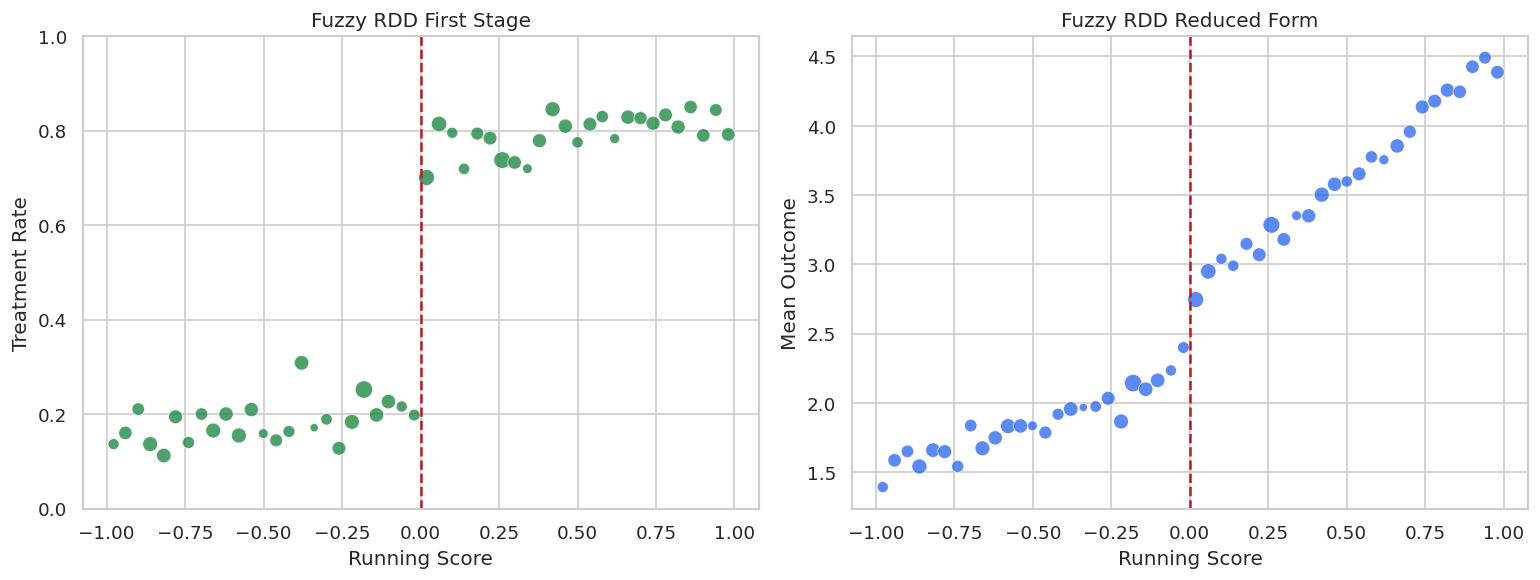

In [16]:
# Build and label the diagnostic visualization for the Fuzzy First Stage Plot section.
fuzzy_bins = np.linspace(-1, 1, 51)
fuzzy_df["score_bin"] = pd.cut(fuzzy_df["running_score"], bins=fuzzy_bins, include_lowest=True)
fuzzy_bin_summary = (
    fuzzy_df.groupby("score_bin", observed=True)
    .agg(
        bin_mid=("running_score", "mean"),
        treatment_rate=("treatment", "mean"),
        mean_outcome=("outcome", "mean"),
        n=("outcome", "size"),
    )
    .reset_index(drop=True)
)
save_table(fuzzy_bin_summary, f"{NOTEBOOK_PREFIX}_fuzzy_binned_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=fuzzy_bin_summary, x="bin_mid", y="treatment_rate", size="n", sizes=(25, 110), color="#15803d", alpha=0.75, legend=False, ax=axes[0])
axes[0].axvline(CUTOFF, color="#b91c1c", linestyle="--", linewidth=1.5)
axes[0].set_title("Fuzzy RDD First Stage")
axes[0].set_xlabel("Running Score")
axes[0].set_ylabel("Treatment Rate")
axes[0].set_ylim(0, 1)

sns.scatterplot(data=fuzzy_bin_summary, x="bin_mid", y="mean_outcome", size="n", sizes=(25, 110), color="#2563eb", alpha=0.75, legend=False, ax=axes[1])
axes[1].axvline(CUTOFF, color="#b91c1c", linestyle="--", linewidth=1.5)
axes[1].set_title("Fuzzy RDD Reduced Form")
axes[1].set_xlabel("Running Score")
axes[1].set_ylabel("Mean Outcome")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fuzzy_first_stage_and_reduced_form.png", dpi=160, bbox_inches="tight")
plt.show()


The treatment rate jumps at the cutoff. The outcome also jumps, but the fuzzy treatment effect is the outcome jump divided by the treatment jump.

#### Fuzzy RDD Estimates

We estimate the fuzzy RDD with both `rdrobust` and `RDFlex`. `RDFlex` receives an outcome learner and a treatment learner because treatment is no longer deterministic at the cutoff.

In [17]:
# Fit or evaluate the model objects used in the Fuzzy RDD Estimates section.
rdrobust_fuzzy = rdrobust(
    y=fuzzy_df["outcome"].to_numpy(),
    x=fuzzy_df["running_score"].to_numpy(),
    fuzzy=fuzzy_df["treatment"].to_numpy(),
    c=CUTOFF,
)
rdrobust_fuzzy_summary = rdrobust_summary(rdrobust_fuzzy, "rdrobust fuzzy", "fuzzy RDD", TRUE_FUZZY_EFFECT)

fuzzy_manual = []
for h in [0.18, 0.24, 0.30, 0.40]:
    row = local_linear_rdd(
        fuzzy_df,
        y_col="outcome",
        score_col="running_score",
        cutoff=CUTOFF,
        bandwidth=h,
        covariates=feature_cols,
        fuzzy_d_col="treatment",
    )
    row.update({"estimator": "Manual fuzzy local linear + covariates", "true_target": TRUE_FUZZY_EFFECT})
    row["bias_vs_target"] = row["estimate"] - TRUE_FUZZY_EFFECT
    fuzzy_manual.append(row)
fuzzy_manual_summary = pd.DataFrame(fuzzy_manual)

fuzzy_rdd_data = DoubleMLRDDData(
    fuzzy_df,
    y_col="outcome",
    d_cols="treatment",
    score_col="running_score",
    x_cols=feature_cols,
)
fuzzy_g = HistGradientBoostingRegressor(
    max_iter=80,
    max_leaf_nodes=15,
    min_samples_leaf=25,
    learning_rate=0.06,
    random_state=RANDOM_SEED + 21,
)
fuzzy_m = HistGradientBoostingClassifier(
    max_iter=80,
    max_leaf_nodes=15,
    min_samples_leaf=25,
    learning_rate=0.06,
    random_state=RANDOM_SEED + 22,
)
rdflex_fuzzy = RDFlex(
    fuzzy_rdd_data,
    ml_g=fuzzy_g,
    ml_m=fuzzy_m,
    fuzzy=True,
    cutoff=CUTOFF,
    n_folds=5,
    h_fs=0.40,
)
rdflex_fuzzy.fit(n_iterations=1)
rdflex_fuzzy_summary = rdflex_summary(rdflex_fuzzy, "RDFlex fuzzy HGB", "fuzzy RDD", TRUE_FUZZY_EFFECT)

save_table(rdrobust_fuzzy_summary, f"{NOTEBOOK_PREFIX}_rdrobust_fuzzy_summary.csv")
save_table(fuzzy_manual_summary, f"{NOTEBOOK_PREFIX}_manual_fuzzy_bandwidth_sensitivity.csv")
save_table(rdflex_fuzzy_summary, f"{NOTEBOOK_PREFIX}_rdflex_fuzzy_summary.csv")

print(rdrobust_fuzzy)
display(rdrobust_fuzzy_summary)
display(fuzzy_manual_summary)
display(rdflex_fuzzy_summary)


Call: rdrobust
Number of Observations:                  5000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          2493       2507
Number of Unique Obs.           2493       2507
Number of Effective Obs.        1021       1037
Bandwidth Estimation           0.408      0.408
Bandwidth Bias                 0.617      0.617
rho (h/b)                      0.661      0.661

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.835    0.153    5.446   5.154e-08     [0.534, 1.135]
Robust                 -        -    4.069   4.720e-05     [0.388, 1.109]



,estimator,design,theta_hat,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,rdrobust fuzzy - Conventional,fuzzy RDD,0.834834,0.534380,1.135288,1.0,-0.165166
1,rdrobust fuzzy - Bias-Corrected,fuzzy RDD,0.748283,0.447829,1.048737,1.0,-0.251717
2,rdrobust fuzzy - Robust,fuzzy RDD,0.748283,0.387857,1.108709,1.0,-0.251717


,bandwidth,n_window,n_left,n_right,estimate,std_error,ci_95_lower,ci_95_upper,reduced_form_jump,first_stage_jump,estimator,true_target,bias_vs_target
0,0.18,908,455,453,0.984543,0.230390,0.532979,1.436106,0.514370,0.522446,Manual fuzzy local linear + covariates,1.0,-0.015457
1,0.24,1233,627,606,0.989449,0.194074,0.609063,1.369834,0.535428,0.541138,Manual fuzzy local linear + covariates,1.0,-0.010551
2,0.30,1555,772,783,1.009756,0.175413,0.665946,1.353565,0.547735,0.542443,Manual fuzzy local linear + covariates,1.0,0.009756
3,0.40,2017,1002,1015,1.022569,0.153939,0.720849,1.324290,0.559048,0.546709,Manual fuzzy local linear + covariates,1.0,0.022569


,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,RDFlex fuzzy HGB - Conventional,fuzzy RDD,1.044896,0.121252,0.807246,1.282546,1.0,0.044896
1,RDFlex fuzzy HGB - Bias-Corrected,fuzzy RDD,1.030109,0.121252,0.792459,1.267759,1.0,0.030109
2,RDFlex fuzzy HGB - Robust,fuzzy RDD,1.030109,0.142139,0.751522,1.308696,1.0,0.030109


The fuzzy estimates are close to the true local treatment effect. They are less precise than the sharp estimates because the cutoff only partially shifts treatment.



#### Fuzzy Estimate Comparison

The fuzzy comparison plot shows the robust `rdrobust` estimate, the `RDFlex` robust estimate, and a manual local-linear estimate at a representative bandwidth.

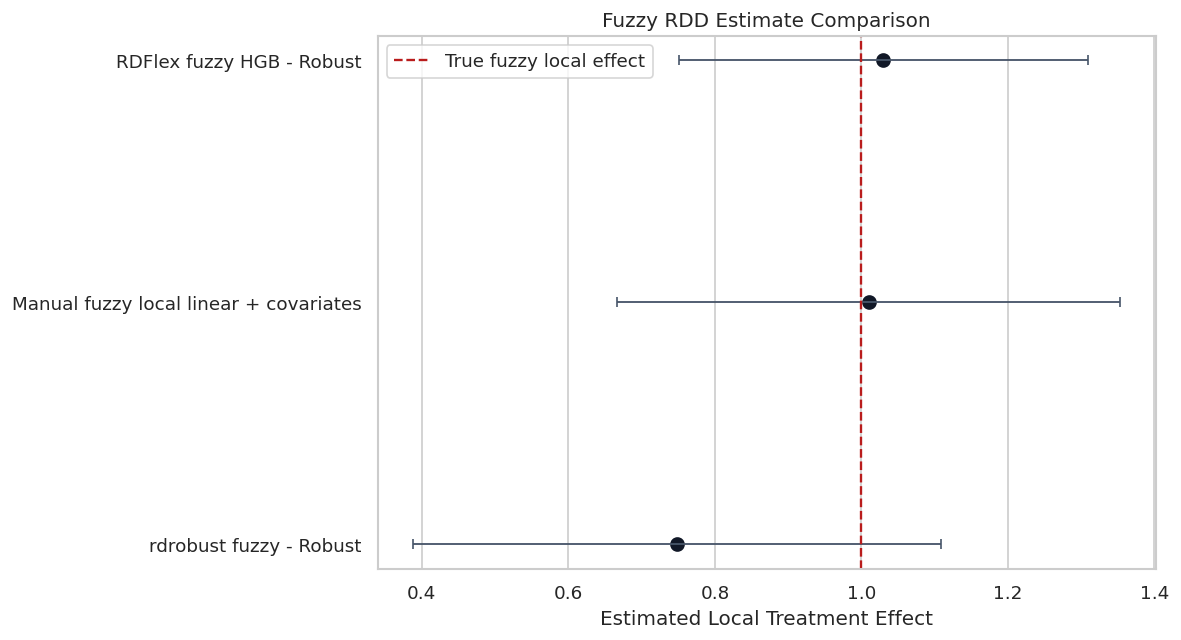

In [18]:
# Build and label the diagnostic visualization for the Fuzzy Estimate Comparison section.
fuzzy_manual_primary = fuzzy_manual_summary.query("bandwidth == 0.30").copy()
fuzzy_manual_primary = fuzzy_manual_primary.rename(columns={"estimate": "theta_hat"})
fuzzy_manual_primary["design"] = "fuzzy RDD"
fuzzy_manual_primary = fuzzy_manual_primary[["estimator", "design", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "true_target", "bias_vs_target"]]

fuzzy_estimate_comparison = pd.concat(
    [
        rdrobust_fuzzy_summary.loc[rdrobust_fuzzy_summary["estimator"] == "rdrobust fuzzy - Robust"].assign(std_error=np.nan),
        rdflex_fuzzy_summary.loc[rdflex_fuzzy_summary["estimator"] == "RDFlex fuzzy HGB - Robust"],
        fuzzy_manual_primary,
    ],
    ignore_index=True,
    sort=False,
)
save_table(fuzzy_estimate_comparison, f"{NOTEBOOK_PREFIX}_fuzzy_estimate_comparison.csv")
plot_fuzzy = add_ci_columns(fuzzy_estimate_comparison)

fig, ax = plt.subplots(figsize=(10, 5.5))
order = plot_fuzzy.sort_values("theta_hat", ascending=False)["estimator"]
sns.pointplot(
    data=plot_fuzzy,
    y="estimator",
    x="theta_hat",
    order=order,
    linestyle="none",
    color="#111827",
    errorbar=None,
    ax=ax,
)
for y_pos, (_, row) in enumerate(plot_fuzzy.set_index("estimator").loc[order].reset_index().iterrows()):
    ax.errorbar(
        x=row["theta_hat"],
        y=y_pos,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="none",
        color="#475569",
        capsize=3,
        linewidth=1.1,
    )
ax.axvline(TRUE_FUZZY_EFFECT, color="#b91c1c", linestyle="--", linewidth=1.4, label="True fuzzy local effect")
ax.set_title("Fuzzy RDD Estimate Comparison")
ax.set_xlabel("Estimated Local Treatment Effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fuzzy_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The fuzzy estimates agree on a positive local treatment effect. The wider intervals reflect the extra uncertainty from estimating the first-stage treatment jump.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Reporting Checklist

RDD reporting should focus on the cutoff design. A polished RDD report should name the running variable, cutoff, bandwidth, local target, and diagnostics.

In [19]:
rdd_reporting_checklist = pd.DataFrame(
    [
        {"topic": "running variable", "question": "What score determines treatment eligibility?", "notebook_answer": "running_score."},
        {"topic": "cutoff", "question": "Where does assignment change?", "notebook_answer": f"Cutoff is {CUTOFF}."},
        {"topic": "design type", "question": "Is treatment sharp or fuzzy at the cutoff?", "notebook_answer": "Both sharp and fuzzy examples are demonstrated."},
        {"topic": "estimand", "question": "Is the effect local or global?", "notebook_answer": "Local effect at the cutoff."},
        {"topic": "support", "question": "Are there enough observations on both sides near the cutoff?", "notebook_answer": "Checked through local window counts."},
        {"topic": "manipulation", "question": "Is there suspicious bunching at the cutoff?", "notebook_answer": "Checked through running-score histograms."},
        {"topic": "covariate continuity", "question": "Do pre-treatment covariates jump at the cutoff?", "notebook_answer": "Checked with local-linear covariate discontinuities."},
        {"topic": "bandwidth", "question": "Does the estimate change across reasonable bandwidths?", "notebook_answer": "Checked through bandwidth sensitivity."},
        {"topic": "fuzzy first stage", "question": "Does cutoff crossing shift treatment probability?", "notebook_answer": "Checked in the fuzzy first-stage plot."},
    ]
)
save_table(rdd_reporting_checklist, f"{NOTEBOOK_PREFIX}_rdd_reporting_checklist.csv")
display(rdd_reporting_checklist)


,topic,question,notebook_answer
0,running variable,What score determines treatment eligibility?,running_score.
1,cutoff,Where does assignment change?,Cutoff is 0.0.
2,design type,Is treatment sharp or fuzzy at the cutoff?,Both sharp and fuzzy examples are demonstrated.
3,estimand,Is the effect local or global?,Local effect at the cutoff.
4,support,Are there enough observations on both sides near the cutoff?,Checked through local window counts.
5,manipulation,Is there suspicious bunching at the cutoff?,Checked through running-score histograms.
6,covariate continuity,Do pre-treatment covariates jump at the cutoff?,Checked with local-linear covariate discontinuities.
7,bandwidth,Does the estimate change across reasonable bandwidths?,Checked through bandwidth sensitivity.
8,fuzzy first stage,Does cutoff crossing shift treatment probability?,Checked in the fuzzy first-stage plot.


This checklist keeps the RDD estimate connected to its design. The strongest RDD reports are usually visual and diagnostic, more than model-summary tables.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


### Report Template

The report template below writes a concise RDD summary using the preferred robust rows. It also states the local nature of the effect.

In [20]:
best_sharp = sharp_estimate_comparison.loc[sharp_estimate_comparison["estimator"] == "RDFlex sharp HGB - Robust"].iloc[0]
best_fuzzy = fuzzy_estimate_comparison.loc[fuzzy_estimate_comparison["estimator"] == "RDFlex fuzzy HGB - Robust"].iloc[0]

report_text = f"""
# Regression Discontinuity DoubleML Report Template

## Question

Estimate the local treatment effect at a cutoff in the running variable.

## Sharp RDD Result

The preferred sharp estimate uses `RDFlex` with gradient boosting nuisance adjustment and the robust interval.

- Estimate: {best_sharp['theta_hat']:.4f}
- 95 percent CI: [{best_sharp['ci_95_lower']:.4f}, {best_sharp['ci_95_upper']:.4f}]
- Synthetic true cutoff effect: {TRUE_SHARP_EFFECT:.4f}

## Fuzzy RDD Result

The preferred fuzzy estimate uses `RDFlex` with outcome and treatment nuisance adjustment.

- Estimate: {best_fuzzy['theta_hat']:.4f}
- 95 percent CI: [{best_fuzzy['ci_95_lower']:.4f}, {best_fuzzy['ci_95_upper']:.4f}]
- Synthetic true local effect: {TRUE_FUZZY_EFFECT:.4f}

## Identification Assumptions

The design requires potential outcomes to be smooth through the cutoff in the absence of treatment. It also requires no precise manipulation of the running variable around the cutoff. For fuzzy RDD, crossing the cutoff must create a meaningful first-stage change in treatment probability.

## Diagnostics To Include

- Running-variable density around the cutoff.
- Binned outcome plot with the cutoff marked.
- Local support counts by bandwidth.
- Covariate continuity checks.
- Bandwidth sensitivity.
- First-stage plot for fuzzy RDD.

## Scope

This is a local estimate at the cutoff. It should not be generalized to units far from the cutoff without an additional argument.
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_rdd_report_template.md"
report_path.write_text(report_text)
print(report_text)


# Regression Discontinuity DoubleML Report Template

## Question

Estimate the local treatment effect at a cutoff in the running variable.

## Sharp RDD Result

The preferred sharp estimate uses `RDFlex` with gradient boosting nuisance adjustment and the robust interval.

- Estimate: 1.3002
- 95 percent CI: [1.0932, 1.5071]
- Synthetic true cutoff effect: 1.2000

## Fuzzy RDD Result

The preferred fuzzy estimate uses `RDFlex` with outcome and treatment nuisance adjustment.

- Estimate: 1.0301
- 95 percent CI: [0.7515, 1.3087]
- Synthetic true local effect: 1.0000

## Identification Assumptions

The design requires potential outcomes to be smooth through the cutoff in the absence of treatment. It also requires no precise manipulation of the running variable around the cutoff. For fuzzy RDD, crossing the cutoff must create a meaningful first-stage change in treatment probability.

## Diagnostics To Include

- Running-variable density around the cutoff.
- Binned outcome plot with the cuto

The report template deliberately avoids overclaiming. RDD estimates are often compelling exactly because they are local; stretching them into a global effect can weaken the design.

The RDD notebook is complete. The next natural topic is learner choices, hyperparameters, and tuning without leakage.
